In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire un fichier CSV et créer un DataFrame
df = pd.read_csv('activites_brutes.csv')

# Afficher les premières lignes
print(df.head())

# Afficher les informations du DataFrame
print(df.info())

   resource_state                                 athlete  \
0               2  {'id': 124945657, 'resource_state': 1}   
1               2  {'id': 124945657, 'resource_state': 1}   
2               2  {'id': 124945657, 'resource_state': 1}   
3               2  {'id': 124945657, 'resource_state': 1}   
4               2  {'id': 124945657, 'resource_state': 1}   

                      name  distance  moving_time  elapsed_time  \
0    Course à pied de nuit    7547.9         1822          1833   
1          10*400 moy 3:01    9561.0         2283          2496   
2          10*400 Moy 3:01   12299.0         2828          3084   
3    Course à pied de nuit   16425.0         3717          3881   
4  Course à pied en soirée    8721.5         2130          2425   

   total_elevation_gain type sport_type  workout_type  ... elev_high  \
0                  73.0  Run        Run           NaN  ...     102.0   
1                  13.0  Run        Run           NaN  ...     112.0   
2             

# Analyse globale des éléments 


In [120]:
nb_colonnes = df.shape[1]
nb_lignes = df.shape[0]
print(f"Nombre de colonnes : {nb_colonnes}")
print(f"Nombre de lignes : {nb_lignes}") # on affiche le nombre de lignes celle-ci sont au nombre de 200. L'extraction entraine une 
# Une perte d'information. 
# Création d'un petit tableau récapitulatif
types_colonnes = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs non-nulles': df.count(),
    'Exemple': df.iloc[0] if len(df) > 0 else "N/A"
})

print(types_colonnes)

Nombre de colonnes : 57
Nombre de lignes : 571
                                  Type  Valeurs non-nulles  \
resource_state                   int64                 571   
athlete                            str                 571   
name                               str                 571   
distance                       float64                 571   
moving_time                      int64                 571   
elapsed_time                     int64                 571   
total_elevation_gain           float64                 571   
type                               str                 571   
sport_type                         str                 571   
workout_type                   float64                  98   
device_name                        str                 571   
id                               int64                 571   
start_date                         str                 571   
start_date_local                   str                 571   
timezone               

Suppression des colonnes unutile 

## Netoyage des données 

In [121]:
# 1. Ta sélection de colonnes (Zone Silver)
colonnes_souhaitees = [
    'start_date_local', 'name', 'type', 'distance', 'moving_time', 
    'total_elevation_gain', 'average_speed', 'max_speed', 
    'average_heartrate', 'max_heartrate', 'suffer_score', 
    'location_city', 'average_cadence', 'average_temp', 'kilojoules'
]

# 2. Filtrage intelligent des activités (Run uniquement)
# Liste des types officiels Strava pour la course
types_run_officiels = ['Run', 'TrailRun', 'VirtualRun']

# Liste de mots-clés pour identifier la course dans le nom (au cas où)
mots_cles_run = ['run', 'course', 'trail', '400', 'séance', 'entraînement']

# On filtre : soit le type est 'Run', soit le nom contient un mot-clé de course
# (en ignorant les majuscules avec .str.lower())
masque_run = (df['type'].isin(types_run_officiels)) | \
             (df['name'].str.lower().str.contains('|'.join(mots_cles_run), na=False))

# On exclut spécifiquement le vélo et la muscu même s'ils ont un mot-clé
masque_exclure = df['name'].str.lower().str.contains('vélo|musculation|poids|randonnée|marche', na=False)

df_propre = df[masque_run & ~masque_exclure].copy()

# 3. Application de ta sélection de colonnes
colonnes_finales = [c for c in colonnes_souhaitees if c in df_propre.columns]
df_propre = df_propre[colonnes_finales]



In [122]:
print(df_propre[['name']].drop_duplicates())

                                 name
0               Course à pied de nuit
1                     10*400 moy 3:01
2                     10*400 Moy 3:01
4             Course à pied en soirée
8     Course à pied dans l'après-midi
9          Bla-bla run avec les girls
14             Course à pied le matin
17                         Pas facile
36    Pause au involontaire au milieu
74             Course à pied matinale
85   Course à pied le matin avec lulu
109            Entraînement en soirée
112             Course à pied le midi
187                         Montre hs
258                    Trail le matin
314           Trail dans l'après-midi
336             Course à pied du midi
473                     Trail le midi


Converstion des valeurs : 

In [123]:
print(df_propre[['distance','moving_time']])


     distance  moving_time
0      7547.9         1822
1      9561.0         2283
2     12299.0         2828
3     16425.0         3717
4      8721.5         2130
..        ...          ...
565    4994.0         1613
566       6.0            8
567   10000.0         2274
569    4995.0         1013
570       8.0            5

[484 rows x 2 columns]


In [124]:
# Conversion de la distance (m -> km)
if 'distance' in df_propre.columns:
    df_propre['distance_km'] = df_propre['distance'] / 1000
    # Conversion du temps total (sec -> min)
if 'elapsed_time' in df_propre.columns:
    df_propre['elapsed_time_min'] = df_propre['elapsed_time'] / 60

# Optionnel : Conversion du temps de mouvement (sec -> min)
if 'moving_time' in df_propre.columns:
    df_propre['moving_time_min'] = df_propre['moving_time'] / 60
if 'moving_time' in df_propre.columns:
    df_propre['moving_time_s'] = df_propre['moving_time_min'] * 60
# Conversion de la vitesse moyenne (m/s -> km/h)
if 'average_speed' in df_propre.columns:
    df_propre['average_speed_kmh'] = (df_propre['average_speed'] * 3.6).round(2)

# Conversion de la vitesse maximale (m/s -> km/h)
if 'max_speed' in df_propre.columns:
    df_propre['max_speed_kmh'] = (df_propre['max_speed'] * 3.6).round(2)

# Petit test d'affichage pour vérifier le résultat
print("Vérification des vitesses converties :")
print(df_propre[['name', 'average_speed', 'average_speed_kmh']].head())

Vérification des vitesses converties :
                      name  average_speed  average_speed_kmh
0    Course à pied de nuit          4.143              14.91
1          10*400 moy 3:01          4.188              15.08
2          10*400 Moy 3:01          4.349              15.66
3    Course à pied de nuit          4.419              15.91
4  Course à pied en soirée          4.095              14.74


In [125]:
print(df_propre[['distance_km','moving_time_min']])


     distance_km  moving_time_min
0         7.5479        30.366667
1         9.5610        38.050000
2        12.2990        47.133333
3        16.4250        61.950000
4         8.7215        35.500000
..           ...              ...
565       4.9940        26.883333
566       0.0060         0.133333
567      10.0000        37.900000
569       4.9950        16.883333
570       0.0080         0.083333

[484 rows x 2 columns]


In [126]:
# En prévsion d'une  analyse temporelle, on convertit la date de début en format datetime

In [127]:
# Convertir la colonne texte en vrai format Datetime (gère automatiquement les T et Z)
df_propre['start_date_local'] = pd.to_datetime(df_propre['start_date_local'])

# Vérification du nouveau type
print(df_propre['start_date_local'].dtype)
# 1. Extraire l'année (ex: 2026, 2024)
df_propre['annee'] = df_propre['start_date_local'].dt.year

# 2. Extraire le mois sous forme de chiffre (1 à 12)
df_propre['mois_num'] = df_propre['start_date_local'].dt.month

# 3. Extraire le nom du jour en français (lundi, mardi...)
df_propre['jour_semaine'] = df_propre['start_date_local'].dt.day_name()

# 4. Extraire uniquement la date brute (sans les heures/minutes) pour l'affichage
df_propre['date_seule'] = df_propre['start_date_local'].dt.date

# On jette un œil aux nouvelles colonnes créées
df_propre[['start_date_local', 'annee', 'mois_num', 'jour_semaine']].head()

datetime64[us, UTC]


,start_date_local,annee,mois_num,jour_semaine
0,2026-05-15 21:10:05+00:00,2026,5,Friday
1,2026-05-15 19:53:54+00:00,2026,5,Friday
2,2026-05-14 21:49:15+00:00,2026,5,Thursday
3,2026-05-13 22:00:24+00:00,2026,5,Wednesday
4,2026-05-12 20:16:58+00:00,2026,5,Tuesday


In [128]:
print(df_propre['start_date_local'])

0     2026-05-15 21:10:05+00:00
1     2026-05-15 19:53:54+00:00
2     2026-05-14 21:49:15+00:00
3     2026-05-13 22:00:24+00:00
4     2026-05-12 20:16:58+00:00
                 ...           
565   2024-10-30 21:35:16+00:00
566   2024-10-30 21:34:32+00:00
567   2024-10-30 20:44:59+00:00
569   2024-10-29 17:50:30+00:00
570   2024-10-29 17:48:37+00:00
Name: start_date_local, Length: 484, dtype: datetime64[us, UTC]


In [129]:
print(df['average_heartrate'].head())

0    165.8
1    162.3
2    163.9
3    164.8
4    152.8
Name: average_heartrate, dtype: float64


In [130]:
# On enrichie le  dataFrame  par l'ajout de nouvelles colonnes de calcule de VMA, VO2max, 
# indice d'éffort. Dans l'objectif de déterminer 
# [le profil du coureur] , de disposer d'information sufisante pour déterminer le rendement / risque de blessure par 
# [semaine d'entrainement] / par mois / et par trimestre. 

## Le profile du coureur et l'intensité des entrainements 
On commence par la VMA : elle se calcule en divisant la distance parcourue en mètre par le temps de mouvement 
en secondes on multiplie l'ensemble par 3.6.  On veut connaître l'évolution de la VMA de ce courreur. Par Conséquent on doit intégrer 
une dimenssion temporelle. Nous allons calculer la VMA à partir du meilleu temps sur 3min de chaque trimestres. 
Nous ne disposons de données de temps intermédiaire que pour les séances de type fractionnné. Nous optons pour  un calcule de VMA. 
tel que Martti Karvonen (1957) met en place la notion de Fréquence cardique de réserve. $$\text{VMA Estimée} = \frac{\text{Vitesse Actuelle}}{\% \text{ de la Fréquence Cardiaque de Réserve}}$$

Aujourd'hui les phisiologistes ont conclu qu'il existait une relation linéaire entre la  VO2max (capacité à utilisé O2), la vitesse sur plat, et la fréquence cardiaque de réserve. Par conséquent lorsque l'on solicite  75% de sa fréquence cardiaque de réserve nous sollicitons également 75% de la FC de réserve. 


$$\% \text{ d'intensité} = \frac{\text{FC Moyenne} - \text{FC Repos}}{\text{FC Max} - \text{FC Repos}}$$
On considère la FCmax = capacité cardiaque maximum = $$\text{FCMax} = 207 - (0,7 \times \text{Âge})$$
FCrepos = (44)
FC max = 185

Pour éviter les biais, Il nécéssaire de se fonder sur des activités avec un faible denivlé, une température moyenne plustôt basse.  

On fonde un premier indice d'effort théorique : l'enjeu est de le pondérer empiriquement en indentifiant les "facteurs d'effort". 

In [131]:
if 'average_heartrate' in df_propre.columns:
    
    # Calcul de l'indice d'effort de Karvonen (FC Réserve)
    df_propre["indice_d'effort_K"] = (df_propre['average_heartrate'] - 45) / (190 - 45)
    
    # Arrondi à 2 décimales pour un affichage propre (ex: 0.75)
    df_propre["indice_d'effort_K"] = df_propre["indice_d'effort_K"].round(2)
    
    print("Colonne 'indice_d'effort_K' créée avec succès !")
    print("-" * 60)
    # Affichage des 10 premières lignes pour vérifier
    print(df_propre[['name', 'average_heartrate', "indice_d'effort_K"]].head(10))
    


Colonne 'indice_d'effort_K' créée avec succès !
------------------------------------------------------------
                              name  average_heartrate  indice_d'effort_K
0            Course à pied de nuit              165.8               0.83
1                  10*400 moy 3:01              162.3               0.81
2                  10*400 Moy 3:01              163.9               0.82
3            Course à pied de nuit              164.8               0.83
4          Course à pied en soirée              152.8               0.74
5            Course à pied de nuit              165.5               0.83
6          Course à pied en soirée              161.4               0.80
7          Course à pied en soirée              160.2               0.79
8  Course à pied dans l'après-midi              171.7               0.87
9       Bla-bla run avec les girls              162.2               0.81


In [132]:
# Vérification que les deux colonnes nécessaires existent
if 'average_speed_kmh' in df_propre.columns and "indice_d'effort_K" in df_propre.columns:
    
    # Calcul de la VMA estimée (Vitesse / Indice d'effort)
    # On utilise une condition pour éviter la division par zéro (si l'indice est égal à 0)
    df_propre['VMA'] = df_propre.apply(
        lambda row: row['average_speed_kmh'] / row["indice_d'effort_K"] 
        if row["indice_d'effort_K"] > 0 else None, 
        axis=1
    )
    
    # Arrondi à 2 décimales pour que ce soit propre (ex: 16.45)
    df_propre['VMA'] = df_propre['VMA'].round(2)
    
    print("🚀 Colonne 'VMA' (Vitesse Maximale Aérobie estimée en km/h) créée avec succès !")
    print("-" * 75)
    # Affichage d'un aperçu des résultats
    print(df_propre[['name', 'average_speed_kmh', "indice_d'effort_K", 'VMA']].head(10))
    # Print last quarter: prefer existing 'trimestre', else compute from start_date_local
    if 'trimestre' in df_propre.columns:
        print(f"Dernier trimestre : {df_propre['trimestre'].max()}")
    elif 'start_date_local' in df_propre.columns:
        df_propre['trimestre'] = pd.to_datetime(df_propre['start_date_local']).dt.to_period('Q')
        print(f"Dernier trimestre : {df_propre['trimestre'].max()}")
 

🚀 Colonne 'VMA' (Vitesse Maximale Aérobie estimée en km/h) créée avec succès !
---------------------------------------------------------------------------
                              name  average_speed_kmh  indice_d'effort_K  \
0            Course à pied de nuit              14.91               0.83   
1                  10*400 moy 3:01              15.08               0.81   
2                  10*400 Moy 3:01              15.66               0.82   
3            Course à pied de nuit              15.91               0.83   
4          Course à pied en soirée              14.74               0.74   
5            Course à pied de nuit              15.11               0.83   
6          Course à pied en soirée              15.09               0.80   
7          Course à pied en soirée              15.88               0.79   
8  Course à pied dans l'après-midi              15.61               0.87   
9       Bla-bla run avec les girls              14.52               0.81   

     VMA

C:\Users\leopa\AppData\Local\Temp\ipykernel_5836\2531330466.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_propre['trimestre'] = pd.to_datetime(df_propre['start_date_local']).dt.to_period('Q')


On selectionne des activités à faible dénivlé et de même distance  pour assurer un calcule fiable. 

In [133]:

# 1. Définition des conditions de filtrage (Température douce + Plat)

condition_denivele = df_propre['total_elevation_gain'] <= 20
condition_distance = (df_propre['distance_km'] >= 9) & (df_propre['distance_km'] <= 12)

# Application du filtre sur l'ensemble du DataFrame
df_selection = df_propre[condition_denivele & condition_distance].copy()

# 2. Sécurité Date & Filtrage chronologique (2024 à 2026)
df_selection['start_date_local'] = pd.to_datetime(df_selection['start_date_local'])
df_selection = df_selection[df_selection['start_date_local'].dt.year.isin([2024, 2025, 2026])].copy()

# 3. Création de la période par trimestre (ex: 2024Q1, 2024Q2...)
df_selection['trimestre'] = df_selection['start_date_local'].dt.to_period('Q')

# 4. Calcul de la VMA moyenne par trimestre et propagation sur chaque ligne
# .transform('mean') permet d'avoir la même VMA moyenne pour toutes les activités du trimestre
df_selection['VMA_finale'] = df_selection.groupby('trimestre')['VMA'].transform('mean').round(2)

# 5. Affichage du résultat et diagnostic
print(f" Nombre d'entraînements correspondants (2024-2026) : {len(df_selection)} sessions.")
print("-" * 75)

if not df_selection.empty:
    print("Aperçu de tes activités avec la colonne 'VMA_finale' identique par trimestre :")
    print(df_selection[['name', 'start_date_local', 'trimestre', 'VMA', 'VMA_finale']].head(10))
    
    # Petit récapitulatif synthétique pour tes yeux
    print("\n📈 Tableau de synthèse de ta VMA moyenne par trimestre :")
    recap = df_selection.groupby('trimestre')['VMA'].mean().round(2).to_frame(name='VMA_Moyenne_Trimestre')
    print(recap)
    print(f"Dernier trimestre : {df_selection['trimestre'].max()}")


C:\Users\leopa\AppData\Local\Temp\ipykernel_5836\3192805301.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_selection['trimestre'] = df_selection['start_date_local'].dt.to_period('Q')


 Nombre d'entraînements correspondants (2024-2026) : 23 sessions.
---------------------------------------------------------------------------
Aperçu de tes activités avec la colonne 'VMA_finale' identique par trimestre :
                                name          start_date_local trimestre  \
1                    10*400 moy 3:01 2026-05-15 19:53:54+00:00    2026Q2   
14            Course à pied le matin 2026-05-01 09:15:02+00:00    2026Q2   
81           Course à pied en soirée 2026-02-24 19:33:06+00:00    2026Q1   
117            Course à pied le midi 2026-01-25 11:38:15+00:00    2026Q1   
142  Course à pied dans l'après-midi 2025-12-24 17:06:49+00:00    2025Q4   
147          Course à pied en soirée 2025-12-16 19:35:44+00:00    2025Q4   
198          Course à pied en soirée 2025-10-14 18:31:05+00:00    2025Q4   
207          Course à pied en soirée 2025-10-04 19:47:40+00:00    2025Q4   
239           Course à pied le matin 2025-09-05 10:47:22+00:00    2025Q3   
243          Course

In [134]:
df_selection['trimestre']

1      2026Q2
14     2026Q2
81     2026Q1
117    2026Q1
142    2025Q4
147    2025Q4
198    2025Q4
207    2025Q4
239    2025Q3
243    2025Q3
245    2025Q3
247    2025Q3
249    2025Q3
250    2025Q3
251    2025Q3
328    2025Q2
350    2025Q2
370    2025Q2
379    2025Q2
443    2025Q1
470    2025Q1
471    2025Q1
478    2025Q1
Name: trimestre, dtype: period[Q-DEC]

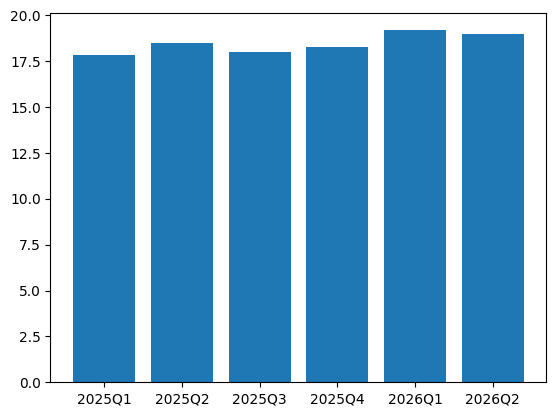

In [135]:
import matplotlib.pyplot as plt

# 1. Préparation des données (une ligne par trimestre, triée par ordre chronologique)
df_plot = (
    df_selection[["trimestre", "VMA_finale"]]
    .drop_duplicates()
    .sort_values("trimestre")
)
df_plot["trimestre_str"] = df_plot["trimestre"].astype(str)

# 2. Le bar plot de base
plt.bar(df_plot["trimestre_str"], df_plot["VMA_finale"])

# 3. Sauvegarde du fichier image
plt.savefig("barplot_vma_base.png")

In [136]:
import pandas as pd

# 1. S'assurer que le trimestre est au format texte pour un affichage propre
df_selection['trimestre_str'] = df_selection['trimestre'].astype(str)

# 2. Création du tableau croisé dynamique (Pivot Table)
tableau_vma = df_selection.pivot_table(
    index='trimestre_str',    # Les lignes du tableau (les trimestres)
    values='VMA',             # La colonne sur laquelle on fait les calculs
    aggfunc=['mean', 'max', 'count'] # Les calculs : Moyenne, Max, et Nombre de courses
)

# 3. Renommer proprement les colonnes pour ton rapport Quarto
tableau_vma.columns = ['VMA_Moyenne', 'VMA_Maximale', 'Nombre_de_Courses']

# Arrondir les résultats à 2 décimales
tableau_vma = tableau_vma.round(2)

# 4. Affichage du tableau croisé dynamique
print("📊 TABLEAU CROISÉ DYNAMIQUE : ÉVOLUTION DE LA VMA")
print("=" * 60)
print(tableau_vma)

📊 TABLEAU CROISÉ DYNAMIQUE : ÉVOLUTION DE LA VMA
               VMA_Moyenne  VMA_Maximale  Nombre_de_Courses
trimestre_str                                              
2025Q1               17.84         18.70                  4
2025Q2               18.49         18.89                  4
2025Q3               18.01         20.24                  7
2025Q4               18.28         18.70                  4
2026Q1               19.19         19.77                  2
2026Q2               18.99         19.36                  2


De la même manière nous allons calculer les meilleurs performances sur 1km  5km 10km 21km 42km

In [137]:

# 1. Sécurité Dates & Filtrage chronologique (2024 à 2026)
df_chronologique = df_propre[df_propre['start_date_local'].dt.year.isin([2024, 2025, 2026])].copy()

# Création de la colonne trimestre en texte (ex: '2024Q1')
df_chronologique['trimestre'] = df_chronologique['start_date_local'].dt.to_period('Q').astype(str)

# 2. Fonction de catégorisation par blocs de distance (avec tolérance GPS de +/- 5%)
def categoriser_distance(dist_km):
    if 0.95 <= dist_km <= 1.05:   return '1 km'
    elif 4.8 <= dist_km <= 5.2:   return '5 km'
    elif 9.7 <= dist_km <= 10.5:  return '10 km'
    elif 20.5 <= dist_km <= 21.300 : return 'Semi-Marathon'
    elif 41.0 <= dist_km <= 43.5: return 'Marathon'
    return None

# Application de la catégorisation
df_chronologique['distance_cible'] = df_chronologique['distance_km'].apply(categoriser_distance)

# On supprime les entraînements qui ne correspondent pas aux distances reines
df_filtre = df_chronologique.dropna(subset=['distance_cible']).copy()

# 3. Extraction du record : on cherche la vitesse max pour CHAQUE trimestre et CHAQUE distance
idx_records = df_filtre.groupby(['trimestre', 'distance_cible'])['average_speed_kmh'].idxmax()
df_records_trimestriels = df_filtre.loc[idx_records].copy()

def formater_chrono(sec):
    heures = int(sec // 3600)
    minutes = int((sec % 3600) // 60)
    secondes = int(sec % 60)
    return f"{heures:02d}:{minutes:02d}:{secondes:02d}" if heures > 0 else f"{minutes:02d}:{secondes:02d}"

# Application du formatage du temps total
df_records_trimestriels['Meilleur Temps'] = df_records_trimestriels['moving_time'].apply(formater_chrono)

# Calcul et formatage de l'allure (min/km)
df_records_trimestriels['allure_dec'] = df_records_trimestriels['moving_time_min'] / df_records_trimestriels['distance_km']
df_records_trimestriels['Allure'] = df_records_trimestriels['allure_dec'].apply(
    lambda x: f"{int(x)}:{int((x - int(x)) * 60):02d} min/km" if pd.notna(x) else "N/A"
)

# 5. Tri logique pour l'affichage (chronologique puis par distance croissante)
ordre_distances = {'1 km': 1, '5 km': 2, '10 km': 3, 'Semi-Marathon': 4, 'Marathon': 5}
df_records_trimestriels['ordre_dist'] = df_records_trimestriels['distance_cible'].map(ordre_distances)
df_final = df_records_trimestriels.sort_values(by=['trimestre', 'ordre_dist'])

# Sélection des colonnes pour le rendu final
tableau_prs = df_final[[
    'trimestre', 'distance_cible', 'Meilleur Temps', 'Allure', 'average_speed_kmh', 'name'
]].copy()

# Renommer les colonnes pour ton rapport Quarto
tableau_prs.columns = ['Trimestre', 'Distance', 'Meilleur Temps', 'Allure', 'Vitesse Moyenne (km/h)', 'Nom de la séance']

# 6. Affichage du tableau croisé
print("🏆 TES MEILLEURS CHRONOS (PRs) PAR TRIMESTRE (2024-2026)")
print("=" * 95)
print(tableau_prs.to_string(index=False))

🏆 TES MEILLEURS CHRONOS (PRs) PAR TRIMESTRE (2024-2026)
Trimestre      Distance Meilleur Temps      Allure  Vitesse Moyenne (km/h)                Nom de la séance
   2024Q4          5 km          16:53 3:22 min/km                   17.78         Course à pied en soirée
   2024Q4         10 km          37:54 3:47 min/km                   15.83         Course à pied en soirée
   2025Q1          1 km          03:53 3:53 min/km                   15.42         Course à pied en soirée
   2025Q1          5 km          16:49 3:21 min/km                   17.86         Course à pied en soirée
   2025Q1         10 km          37:11 3:42 min/km                   16.16           Course à pied de nuit
   2025Q1 Semi-Marathon       01:24:19 4:06 min/km                   14.63           Course à pied de nuit
   2025Q1      Marathon       02:50:24 3:58 min/km                   15.10          Course à pied le matin
   2025Q2          5 km          17:03 3:24 min/km                   17.62 Course à pied

C:\Users\leopa\AppData\Local\Temp\ipykernel_5836\2502634294.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_chronologique['trimestre'] = df_chronologique['start_date_local'].dt.to_period('Q').astype(str)


✅ Graphique combiné généré avec succès dans 'barplot_toutes_distances_records.png' !


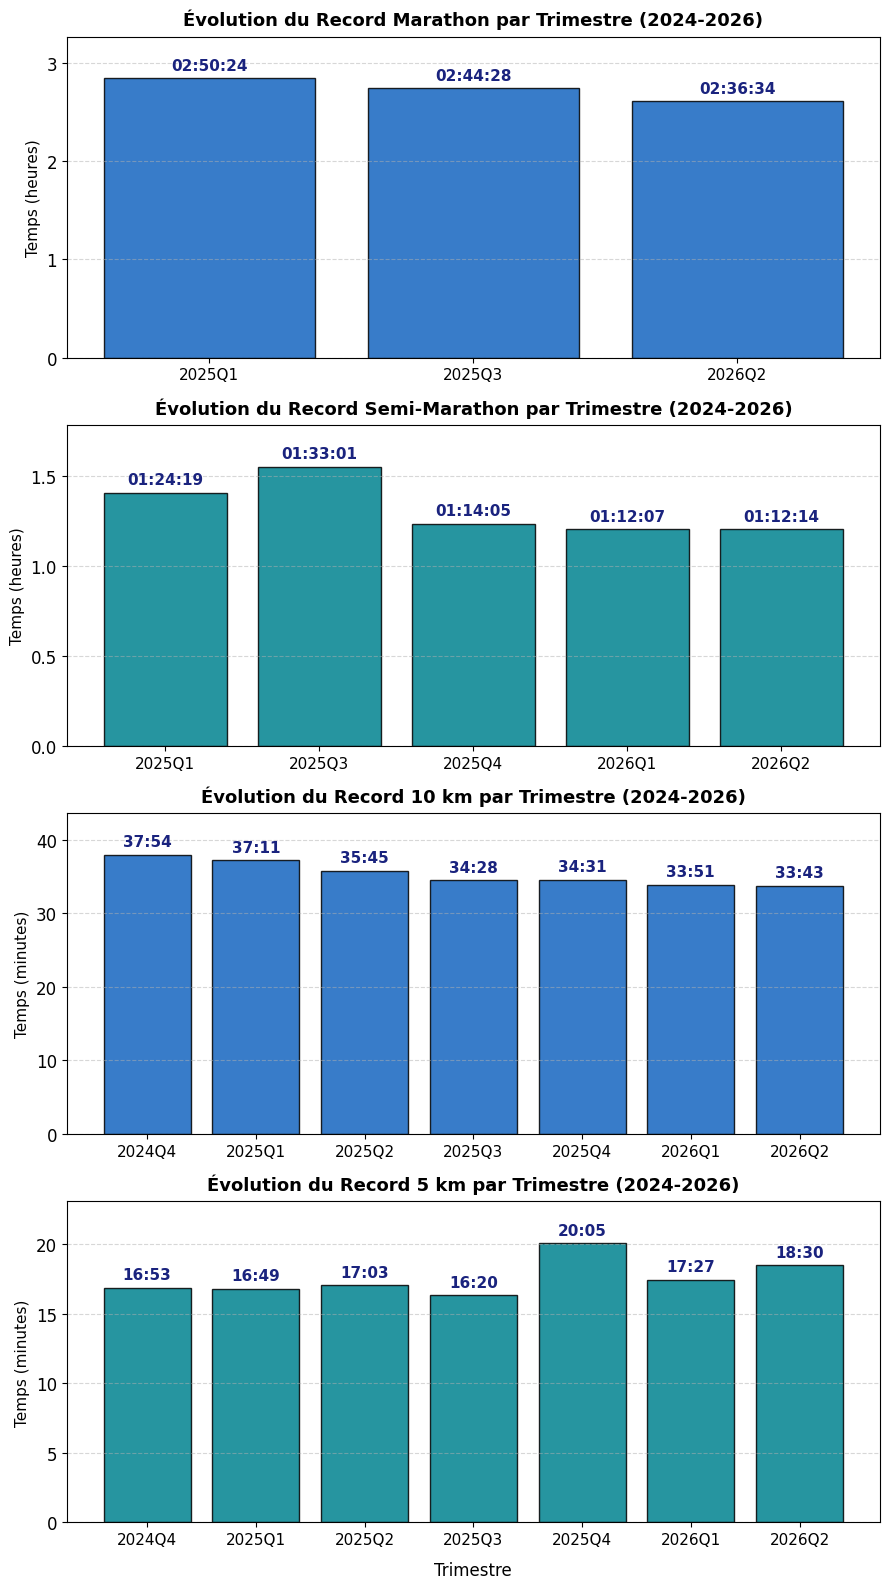

In [138]:
import matplotlib.pyplot as plt

# Liste des distances demandées
distances = ['Marathon', 'Semi-Marathon', '10 km', '5 km']

# 1. Création de la figure avec 4 sous-graphiques alignés verticalement
# On ajuste la taille (figsize) pour que chaque graphique ait de la place
fig, axes = plt.subplots(len(distances), 1, figsize=(9, 4 * len(distances)))

for i, dist in enumerate(distances):
    ax = axes[i] # On sélectionne le sous-graphique du niveau en cours
    
    # Filtrer et trier par trimestre pour la distance concernée
    df_dist = df_final[df_final["distance_cible"] == dist].sort_values("trimestre")
    
    # Sécurité au cas où un trimestre n'a pas encore de donnée pour cette distance
    if df_dist.empty:
        ax.text(0.5, 0.5, f"Aucune course enregistrée sur {dist}", ha='center', va='center', fontsize=12, color='gray')
        ax.set_title(f"Évolution du Record {dist}", fontsize=12, fontweight='bold')
        continue
        
    # 2. Adaptation de l'unité selon la distance pour éviter d'écraser le graphique
    if dist in ['Marathon', 'Semi-Marathon']:
        df_dist["temps_graphique"] = df_dist["moving_time"] / 3600
        unite = "heures"
    else:
        df_dist["temps_graphique"] = df_dist["moving_time"] / 60
        unite = "minutes"
        
    df_dist["trimestre_str"] = df_dist["trimestre"].astype(str)
    
    # 3. Création du bar plot (alternance de couleurs pour l'esthétique)
    couleur = '#1565C0' if i % 2 == 0 else '#00838F'
    barres = ax.bar(df_dist["trimestre_str"], df_dist["temps_graphique"], color=couleur, edgecolor='black', alpha=0.85)
    
    # --- AJUSTEMENTS DES AXES Y ET X ---
    ax.tick_params(axis='y', labelsize=12) 
    ax.tick_params(axis='x', labelsize=11) 
    ax.locator_params(axis='y', nbins=6) # Nombre de graduations épuré par bloc
    
    # On augmente dynamiquement la limite supérieure de l'axe Y (+15%) 
    # pour laisser de la place aux textes des chronos sans qu'ils soient coupés
    max_val = df_dist["temps_graphique"].max()
    ax.set_ylim(0, max_val * 1.15)
    
    # --- INSCRIPTION DU TEMPS RECORD SUR CHAQUE BARRE ---
    for barre, chrono in zip(barres, df_dist["Meilleur Temps"]):
        hauteur = barre.get_height()
        ax.text(
            barre.get_x() + barre.get_width() / 2, # Centré horizontalement
            hauteur + (max_val * 0.02),           # Positionné juste au-dessus du sommet
            chrono,                               # Ton chrono au format running (ex: 33:00)
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            color='#1A237E'
        )
        
    # Personnalisation des titres et labels de chaque bloc
    ax.set_ylabel(f"Temps ({unite})", fontsize=11)
    ax.set_title(f"Évolution du Record {dist} par Trimestre (2024-2026)", fontsize=13, fontweight='bold', pad=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5) # Ajout d'une grille légère de lecture

# Axe X principal tout en bas
plt.xlabel("Trimestre", fontsize=12, labelpad=10)

# 4. Sauvegarde globale du fichier image
plt.tight_layout() 
plt.savefig("barplot_toutes_distances_records.png", dpi=300)
print("✅ Graphique combiné généré avec succès dans 'barplot_toutes_distances_records.png' !")

On compare la courbe de progression de  chaque disciplines (1km, 5km, 10km, semi-marathon, marathon) pour voir si tu progresses plus sur une distance que sur une autre.         

On regarde l'indice d'effort sur 10km pour constater la logique de forme = même distance meilleur temps  effort inférieur ou égale ou meilleur temps précédent. 

In [205]:

# ==============================================================================
# 1. CONVERSION ET NETTOYAGE DES DATES ET DES DONNÉES
# ==============================================================================
# On s'assure que la colonne des dates est bien reconnue comme une date par Python
if "start_date_local" in df_final.columns:
    df_final["start_date_local"] = pd.to_datetime(df_final["start_date_local"], errors="coerce")

# On s'assure que l'indice K est bien au format numérique
nom_colonne_k = "indice_d'effort_K"
df_final[nom_colonne_k] = pd.to_numeric(df_final[nom_colonne_k], errors="coerce")


# ==============================================================================
# 2. FILTRAGE SÉCURISÉ (DISTANCE ET MEILLEUR TEMPS RENSEIGNÉ)
# ==============================================================================
colonne_distance = "distance_km" if "distance_km" in df_final.columns else "Distance"

df_best_time = df_final[
    df_final[colonne_distance].between(10 , 11) & 
    df_final["Meilleur Temps"].notna() &
    df_final["start_date_local"].notna()
].copy()


# ==============================================================================
# 3. EXTRACTION DU TRIMESTRE ET GÉNERATION DU TABLEAU CROISÉ
# ==============================================================================
if not df_best_time.empty:
    # On extrait le trimestre sous la forme 'AAAA-QX' (ex: 2026-Q1)
    df_best_time["trimestre"] = df_best_time["start_date_local"].dt.to_period("Q").astype(str)

    # Création du tableau croisé dynamique
    table_trimestre_k = df_best_time.pivot_table(
        index=["trimestre", "Meilleur Temps"],
        values=nom_colonne_k,
        aggfunc="mean"
    ).round(3)

    print("TABLEAU : INDICE D'EFFORT K MOYEN SUR LES MEILLEURS TEMPS PAR TRIMESTRE")
    print("=" * 75)
    print(table_trimestre_k)
else:
    print("Aucune donnée ne correspond aux critères (dates manquantes ou pas de 'Meilleur temps').")

TABLEAU : INDICE D'EFFORT K MOYEN SUR LES MEILLEURS TEMPS PAR TRIMESTRE
                          indice_d'effort_K
trimestre Meilleur Temps                   
2024Q4    37:54                        0.92
2025Q1    37:11                        0.84
2025Q2    35:45                        0.91
2025Q3    34:28                        0.86
2025Q4    34:31                        0.89
2026Q2    33:43                        0.92


C:\Users\leopa\AppData\Local\Temp\ipykernel_5836\4025591939.py:30: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_best_time["trimestre"] = df_best_time["start_date_local"].dt.to_period("Q").astype(str)


In [139]:
import pandas as pd

# Liste des distances demandées
distances = ['Marathon', 'Semi-Marathon', '10 km', '5 km']

print("📈 ANALYSE DE LA PROGRESSION PAR DISTANCE")
print("=" * 60)

for dist in distances:
    
    df_dist = df_final[df_final["distance_cible"] == dist]
    

    if df_dist.empty:
        continue
    
    meilleur_temps = df_dist['moving_time_min'].min()
    

    pire_temps = df_dist['moving_time_min'].max()
    

    temps_gagne = pire_temps - meilleur_temps
    
   
    pourcentage_progression = (temps_gagne / pire_temps) * 100
    
    # Affichage des résultats
    print(f"🔹 Distance : {dist}")
    print(f"   Meilleur chrono : {meilleur_temps:.1f} min | Pire chrono : {pire_temps:.1f} min")
    print(f"   Progression     : -{temps_gagne:.1f} min ({pourcentage_progression:.1f}%)")
    print("-" * 60)
     
         


📈 ANALYSE DE LA PROGRESSION PAR DISTANCE
🔹 Distance : Marathon
   Meilleur chrono : 156.6 min | Pire chrono : 170.4 min
   Progression     : -13.8 min (8.1%)
------------------------------------------------------------
🔹 Distance : Semi-Marathon
   Meilleur chrono : 72.1 min | Pire chrono : 93.0 min
   Progression     : -20.9 min (22.5%)
------------------------------------------------------------
🔹 Distance : 10 km
   Meilleur chrono : 33.7 min | Pire chrono : 37.9 min
   Progression     : -4.2 min (11.0%)
------------------------------------------------------------
🔹 Distance : 5 km
   Meilleur chrono : 16.3 min | Pire chrono : 20.1 min
   Progression     : -3.8 min (18.7%)
------------------------------------------------------------


Nous essayons de comprendres quelles éléments ont un inncidence sur  l'indice d'effort précédement construit. Pour cela il faut merge les deux dataframe df_propre et df final. 

In [140]:
# Check if the column exists in df_final
if "indice_d'effort_K" in df_final.columns:
    print(df_final["indice_d'effort_K"])
else:
    # If it doesn't exist, we need to add it back
    # First, merge with df_propre to get the missing column
    df_final = df_final.merge(
        df_propre[['name', 'start_date_local', "indice_d'effort_K"]], 
        on=['name', 'start_date_local'], 
        how='left'
    )
    print(df_final["indice_d'effort_K"])

540    0.91
567    0.92
429    0.77
446    0.95
460    0.84
449    0.84
422    0.89
353    0.90
350    0.91
285    0.87
247    0.86
280    0.78
246    0.85
208    0.82
161    0.77
172    0.89
168    0.94
87     0.89
74     0.90
43     0.92
38     0.81
14     0.92
36     0.88
19     0.90
Name: indice_d'effort_K, dtype: float64


In [141]:
# Check if the column exists in df_final
if "indice_d'effort_K" in df_final.columns:
    print(df_final["indice_d'effort_K"])
else:
    # If it doesn't exist, we need to add it back
    # First, merge with df_propre to get the missing column
    df_final = df_final.merge(
        df_propre[['name', 'start_date_local', "indice_d'effort_K"]], 
        on=['name', 'start_date_local'], 
        how='left'
    )
    print(df_final["indice_d'effort_K"])

540    0.91
567    0.92
429    0.77
446    0.95
460    0.84
449    0.84
422    0.89
353    0.90
350    0.91
285    0.87
247    0.86
280    0.78
246    0.85
208    0.82
161    0.77
172    0.89
168    0.94
87     0.89
74     0.90
43     0.92
38     0.81
14     0.92
36     0.88
19     0.90
Name: indice_d'effort_K, dtype: float64


In [142]:
# 1. Filtrage et copie sécurisée
if "distance_km" in df_final.columns:
    # sélectionner les séances ~10 km avec tolérance GPS
    df_10k = df_final[df_final["distance_km"].between(1.7, 43.5)].copy()


# 2. Création des catégories de température
def categoriser_temp(temp):
    if pd.isna(temp):
        return "Inconnue"
    elif temp < 15:
        return "temp_froide (<15C)"
    elif 15 <= temp <= 25:
        return "temp_douce (15-25C)"
    else:
        return "temp_forte (>25C)"

df_10k["condition_temp"] = df_10k["average_temp"].apply(categoriser_temp)


# 3. VERIFICATION ET DETECTION DE L'ERREUR
# On cherche le nom exact de ta colonne d'indice d'effort
nom_colonne_k = "indice_d'effort_K"

if nom_colonne_k not in df_10k.columns:
    print("Erreur de nom de colonne détectée !")
    print("Voici la liste des colonnes disponibles dans ton tableau :")
    print(list(df_10k.columns))
    print("\nTrouve le nom exact de ton indice K dans cette liste et remplace-le dans le code.")
else:
    # Si la colonne existe, le tableau croisé s'exécute normalement
    table_temp_k = df_10k.pivot_table(
        index="condition_temp",
        values=nom_colonne_k,
        aggfunc="mean"
    ).round(3)

    print("TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR CONDITION DE TEMPERATURE (10 KM)")
    print("=" * 70)
    print(table_temp_k)

TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR CONDITION DE TEMPERATURE (10 KM)
                     indice_d'effort_K
condition_temp                        
Inconnue                         0.881
temp_douce (15-25C)              0.882
temp_forte (>25C)                0.845
temp_froide (<15C)               0.886


In [143]:
df_final['distance_km']

540     5.0030
567    10.0000
429     0.9980
446     5.0070
460    10.0140
449    20.5540
422    42.8760
353     5.0070
350    10.0180
285     5.0070
247    10.0020
280    21.1010
246    42.9730
208     1.0040
161     4.9530
172    10.0100
168    21.2053
87      5.1000
74      9.8562
43     20.9410
38      4.9440
14     10.0048
36     20.9080
19     42.3270
Name: distance_km, dtype: float64

In [144]:

# 1. Filtrage et copie sécurisée
if "distance_km" in df_final.columns:
    # sélectionner les séances ~10 km avec tolérance GPS
    df_10k = df_final[df_final["distance_km"].between(1.7, 43.5)].copy()


# 2. Création des catégories de température
def categoriser_elev(elev):
    if pd.isna(elev):
        return "Inconnue"
    elif elev < 30:
        return "low_elevation (<30m)"
    elif 30 <= elev <= 60:
        return "medium_elevation (30-60m)"
    elif elev > 60:
        return "high_elevation (>60m)"
    else:
        return "Inconnue"

df_10k["condition_elevation"] = df_10k["total_elevation_gain"].apply(categoriser_elev)


# 3. VERIFICATION ET DETECTION DE L'ERREUR
# On cherche le nom exact de ta colonne d'indice d'effort
nom_colonne_k = "indice_d'effort_K"


if nom_colonne_k in df_10k.columns:
    # Si la colonne existe, le tableau croisé s'exécute normalement
    table_temp_k2 = df_10k.pivot_table(
        index="condition_elevation",
        values=nom_colonne_k,
        aggfunc="mean"
    ).round(3)
if nom_colonne_k in df_10k.columns:
    # Si la colonne existe, le tableau croisé s'exécute normalement
    table_temp_k3 = df_10k.pivot_table(
        index="condition_elevation",
        values=nom_colonne_k,
        aggfunc="max"
    ).round(3)

    print("TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR CONDITION DE ELEVATION (10 KM)")
    print("=" * 70)
    print(table_temp_k2)
    print("TABLEAU 2 : INDICE D'EFFORT K MAXIMAL PAR CONDITION DE ELEVATION (10 KM)")
    print("=" * 70)
    print(table_temp_k3)

TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR CONDITION DE ELEVATION (10 KM)
                           indice_d'effort_K
condition_elevation                         
high_elevation (>60m)                  0.878
low_elevation (<30m)                   0.887
medium_elevation (30-60m)              0.810
TABLEAU 2 : INDICE D'EFFORT K MAXIMAL PAR CONDITION DE ELEVATION (10 KM)
                           indice_d'effort_K
condition_elevation                         
high_elevation (>60m)                   0.94
low_elevation (<30m)                    0.95
medium_elevation (30-60m)               0.81


D'après ces chiffres il semblerait que l'effort est corrélé à la température. L'incidence de la température semble moindre. 

La notion de cadence est également essentielle pour comprendre la l'instensité 

In [ ]:
print(df_final['average_cadence'].max())# On voit que le  cadence max est de 92 ce qui n'est 
# pas réaliste pour un coureur. Il s'agit probablement d'une erreur de saisie ou d'un problème de capteur.

100.0


In [151]:
# Conversion de la cadence moyenne et maximale en ppm (pas par minute)
# On suppose que tes colonnes d'origine s'appellent 'average_cadence' et 'max_cadence'
df_final["average_cadence_ppm"] = df_final["average_cadence"] * 2


colonnes_cadence = [c for c in ["start_date_local", "average_cadence_ppm", "max_cadence_ppm"] if c in df_final.columns]
if colonnes_cadence:
    print(df_final[colonnes_cadence].max())

start_date_local       2026-05-01 09:15:02+00:00
average_cadence_ppm                        200.0
dtype: object


In [150]:
# 1. Filtrage et copie sécurisée
if "distance_km" in df_final.columns:
    # sélectionner les séances ~10 km avec tolérance GPS
    df_10k = df_final[df_final["distance_km"].between(1.7, 43.5)].copy()


# 2. Création des catégories de température
def categoriser_cad(cad):
    if pd.isna(cad):
        return "Inconnue"
    elif cad < 150:
        return "low_cadence(<150)"
    elif 150 <= cad <= 185:
        return "medium_cadence (150-185)"
    elif cad > 185:
        return "high_cadence (>185)"
    else:
        return "Inconnue"

df_10k["condition_elevation"] = df_10k["average_cadence_ppm"].apply(categoriser_cad)


# 3. VERIFICATION ET DETECTION DE L'ERREUR
# On cherche le nom exact de ta colonne d'indice d'effort
nom_colonne_k = "indice_d'effort_K"


if nom_colonne_k in df_10k.columns:
    # Si la colonne existe, le tableau croisé s'exécute normalement
    table_temp_k2 = df_10k.pivot_table(
        index="condition_elevation",
        values=nom_colonne_k,
        aggfunc="mean"
    ).round(3)
if nom_colonne_k in df_10k.columns:
    # Si la colonne existe, le tableau croisé s'exécute normalement
    table_temp_k3 = df_10k.pivot_table(
        index="condition_elevation",
        values=nom_colonne_k,
        aggfunc="max"
    ).round(3)

    print("TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR CONDITION DE CADENCE")
    print("=" * 70)
    print(table_temp_k2)
    print("TABLEAU 2 : INDICE D'EFFORT K MAXIMAL PAR CONDITION DE CADENCE")
    print("=" * 70)
    print(table_temp_k3)

TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR CONDITION DE CADENCE
                          indice_d'effort_K
condition_elevation                        
high_cadence (>185)                   0.877
medium_cadence (150-185)              0.920
TABLEAU 2 : INDICE D'EFFORT K MAXIMAL PAR CONDITION DE CADENCE
                          indice_d'effort_K
condition_elevation                        
high_cadence (>185)                    0.95
medium_cadence (150-185)               0.92


Le dernier indicateur d'intensité analysé est la typologie du terrain. Nous discrétisons cette variable en deux catégories : le milieu urbain (qualifié de terrain dur) et la campagne (qualifié de terrain meuble). Pour déterminer cette typologie, nous exploitons les coordonnées géographiques des activités via l'API OpenStreetMap ; le processus de rétro-géocodage permet ainsi d'obtenir la localisation exacte et d'en déduire la nature du terrain.

In [169]:
print(df['visibility'] == False)
print(df.columns)

0      False
1      False
2      False
3      False
4      False
       ...  
566    False
567    False
568    False
569    False
570    False
Name: visibility, Length: 571, dtype: bool
Index(['resource_state', 'athlete', 'name', 'distance', 'moving_time',
       'elapsed_time', 'total_elevation_gain', 'type', 'sport_type',
       'workout_type', 'device_name', 'id', 'start_date', 'start_date_local',
       'timezone', 'utc_offset', 'location_city', 'location_state',
       'location_country', 'achievement_count', 'kudos_count', 'comment_count',
       'athlete_count', 'photo_count', 'map', 'trainer', 'commute', 'manual',
       'private', 'visibility', 'flagged', 'gear_id', 'start_latlng',
       'end_latlng', 'average_speed', 'max_speed', 'average_cadence',
       'average_watts', 'max_watts', 'weighted_average_watts', 'device_watts',
       'kilojoules', 'has_heartrate', 'average_heartrate', 'max_heartrate',
       'heartrate_opt_out', 'display_hide_heartrate_option', 'elev_high',
 

In [170]:
# Ajout direct des colonnes de coordonnées de df vers df_final
df_final["start_latlng"] = df["start_latlng"]
df_final["end_latlng"] = df["end_latlng"]

# Optionnel : Vérification du résultat
print("Vérification des nouvelles colonnes intégrées :")
print(df_final[["name", "start_latlng", "end_latlng"]].head())

Vérification des nouvelles colonnes intégrées :
                        name           start_latlng             end_latlng
540  Course à pied en soirée                     []                     []
567  Course à pied en soirée  [48.779469, 2.310682]  [48.784512, 2.326918]
429  Course à pied en soirée  [48.780522, 2.311435]   [48.780304, 2.31323]
446  Course à pied en soirée                     []                     []
460    Course à pied de nuit  [48.779981, 2.313408]  [48.781174, 2.313925]


In [188]:
import time
import pandas as pd
import requests

# ==============================================================================
# 1. FONCTION DE GEOCONDAGE ET D'ANALYSE DU TERRAIN VIA OSM
# ==============================================================================
def analyser_geographie_osm(lat, lon):
    """Interroge OpenStreetMap pour renvoyer la localisation et la nature du terrain."""
    if pd.isna(lat) or pd.isna(lon) or lat is None or lon is None:
        return "Coordonnées manquantes", "Coordonnées manquantes"

    url = "https://nominatim.openstreetmap.org/reverse"
    headers = {"User-Agent": "Master_CNAM_Analyse_Double_Terrain"}
    params = {
        "lat": lat,
        "lon": lon,
        "format": "json",
        "addressdetails": 1,
        "extratags": 1
    }

    try:
        response = requests.get(url, headers=headers, params=params, timeout=5)
        if response.status_code == 200:
            data = response.json()
            adresse = data.get("address", {})
            osm_type = data.get("category", "")
            extratags = data.get("extratags", {})
            surface = extratags.get("surface", "")
            type_infrastructure = data.get("type", "")

            # --- ANALYSE 1 : LOCALISATION (VILLE OU HORS VILLE) ---
            marqueurs_urbains = ["city", "town", "suburb", "borough", "city_district"]
            if any(cle in adresse for cle in marqueurs_urbains):
                emplacement = "Dans la ville"
            else:
                emplacement = "Hors de la ville"

            # --- ANALYSE 2 : TYPOLOGIE (DURE OU MEUBLE) ---
            if surface in ["asphalt", "concrete", "paving_stones", "paved"]:
                typologie = "dure"
            elif surface in ["unpaved", "dirt", "earth", "grass", "gravel", "sand"]:
                typologie = "meuble"
            else:
                infrastructures_dures = ["highway", "building", "railway"]
                types_routes_dures = ["residential", "service", "pedestrian", "footway", "cycleway", "primary", "secondary"]
                
                if osm_type in infrastructures_dures and type_infrastructure in types_routes_dures:
                    typologie = "dure"
                elif type_infrastructure in ["path", "track", "bridleway"] or osm_type in ["natural", "landuse"]:
                    typologie = "meuble"
                else:
                    typologie = "dure" # Par défaut

            return emplacement, typologie

        else:
            return "Erreur API", "Erreur API"
    except Exception:
        return "Erreur de connexion", "Erreur de connexion"


# ==============================================================================
# 2. APPLICATION DIRECTE SUR DF_FINAL
# ==============================================================================

# Initialisation des colonnes cibles directement dans le dataframe principal
df_final["emplacement"] = "Inconnu"
df_final["typologie_terrain"] = "Inconnu"

print("Lancement de l'analyse géographique globale sur df_final...")
print("-" * 85)

for index, ligne in df_final.iterrows():
    lat, lon = None, None

    # Extraction des coordonnées (Cas 1 : colonne unique start_latlng)
    if "start_latlng" in df_final.columns:
        coord = ligne["start_latlng"]
        if isinstance(coord, list) and len(coord) == 2:
            lat, lon = coord[0], coord[1]
        elif isinstance(coord, str) and coord.startswith("["):
            try:
                coord_clean = eval(coord)
                lat, lon = coord_clean[0], coord_clean[1]
            except:
                pass

    # Extraction des coordonnées (Cas 2 : colonnes séparées lat / lon)
    if lat is None or lon is None:
        lat = ligne.get("start_latitude") or ligne.get("start_lat")
        lon = ligne.get("start_longitude") or ligne.get("start_lng") or ligne.get("start_lon")

    # Si les coordonnées sont valides, on interroge l'API
    if lat is not None and lon is not None:
        emp_resultat, typo_resultat = analyser_geographie_osm(lat, lon)
    else:
        emp_resultat, typo_resultat = "Coordonnées introuvables", "Coordonnées introuvables"

    # Stockage immédiat des résultats dans df_final
    df_final.at[index, "emplacement"] = emp_resultat
    df_final.at[index, "typologie_terrain"] = typo_resultat
    
    print(f"Séance : {ligne.get('name', 'Sans nom')} -> Localisation : {emp_resultat} | Terrain : {typo_resultat}")

    # Pause réglementaire de 1 seconde pour respecter OpenStreetMap
    if emp_resultat not in ["Coordonnées introuvables", "Coordonnées manquantes"]:
        time.sleep(1)

print("-" * 85)
print("Analyse terminée ! Les colonnes 'emplacement' et 'typologie_terrain' sont intégrées.")

Lancement de l'analyse géographique globale sur df_final...
-------------------------------------------------------------------------------------
Séance : Course à pied en soirée -> Localisation : Coordonnées introuvables | Terrain : Coordonnées introuvables
Séance : Course à pied en soirée -> Localisation : Dans la ville | Terrain : dure
Séance : Course à pied en soirée -> Localisation : Dans la ville | Terrain : dure
Séance : Course à pied en soirée -> Localisation : Coordonnées introuvables | Terrain : Coordonnées introuvables
Séance : Course à pied de nuit -> Localisation : Dans la ville | Terrain : dure
Séance : Course à pied de nuit -> Localisation : Erreur de connexion | Terrain : Erreur de connexion
Séance : Course à pied le matin -> Localisation : Dans la ville | Terrain : dure
Séance : Course à pied dans l'après-midi -> Localisation : Dans la ville | Terrain : meuble
Séance : Course à pied dans l'après-midi -> Localisation : Dans la ville | Terrain : dure
Séance : Course à pi

In [192]:

# ==============================================================================
# 1. FILTRAGE ET COPIE SECURISEE (DISTANCES ENTRE 1.7 ET 43.5 KM)
# ==============================================================================
if "distance_km" in df_final.columns:
    # Sélection des séances selon ta règle de distance (du 1.7km au Marathon)
    df_analyse = df_final[df_final["distance_km"].between(1.7, 43.5)].copy()
else:
    # Sécurité si la colonne utilise une majuscule
    df_analyse = df_final[df_final["Distance"].between(1.7, 43.5)].copy()


# ==============================================================================
# 2. NETTOYAGE NUMÉRIQUE DE L'INDICE D'EFFORT K
# ==============================================================================
nom_colonne_k = "indice_d'effort_K"

if nom_colonne_k in df_analyse.columns:
    df_analyse[nom_colonne_k] = pd.to_numeric(df_analyse[nom_colonne_k], errors="coerce")


# ==============================================================================
# 3. GÉNÉRATION DES TABLEAUX CROISÉS DYNAMIQUES
# ==============================================================================
# Vérification que l'indice K et les colonnes géographiques existent
if nom_colonne_k in df_analyse.columns and "emplacement" in df_analyse.columns and "typologie_terrain" in df_analyse.columns:
    
    # --- TABLEAU 1 : Effort moyen par Emplacement (Ville vs Extérieur) ---
    table_emplacement_k = df_analyse.pivot_table(
        index="emplacement",
        values=nom_colonne_k,
        aggfunc="mean"
    ).round(3)

    print("TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR LOCALISATION")
    print("=" * 70)
    print(table_emplacement_k)
    print("\n" + "=" * 70 + "\n")

    # --- TABLEAU 2 : Effort moyen par Typologie de Terrain (Dur vs Meuble) ---
    table_terrain_k = df_analyse.pivot_table(
        index="typologie_terrain",
        values=nom_colonne_k,
        aggfunc="mean"
    ).round(3)

    print("TABLEAU 2 : INDICE D'EFFORT K MOYEN PAR TYPOLOGIE DE TERRAIN")
    print("=" * 70)
    print(table_terrain_k)
    
else:
    print("Erreur : Les colonnes requises (indice K, emplacement ou typologie_terrain) sont introuvables.")
    print("Colonnes actuellement disponibles :", list(df_analyse.columns))

TABLEAU 1 : INDICE D'EFFORT K MOYEN PAR LOCALISATION
                          indice_d'effort_K
emplacement                                
Coordonnées introuvables              0.930
Dans la ville                         0.871
Hors de la ville                      0.940


TABLEAU 2 : INDICE D'EFFORT K MOYEN PAR TYPOLOGIE DE TERRAIN
                          indice_d'effort_K
typologie_terrain                          
Coordonnées introuvables              0.930
Erreur de connexion                   0.846
dure                                  0.891
meuble                                0.883


In [194]:
df_final.columns

Index(['start_date_local', 'name', 'type', 'distance', 'moving_time',
       'total_elevation_gain', 'average_speed', 'max_speed',
       'average_heartrate', 'max_heartrate', 'location_city',
       'average_cadence', 'average_temp', 'kilojoules', 'distance_km',
       'moving_time_min', 'moving_time_s', 'average_speed_kmh',
       'max_speed_kmh', 'annee', 'mois_num', 'jour_semaine', 'date_seule',
       'indice_d'effort_K', 'VMA', 'trimestre', 'distance_cible',
       'Meilleur Temps', 'allure_dec', 'Allure', 'ordre_dist',
       'average_cadence_ppm', 'start_latlng', 'end_latlng', 'latitude',
       'longitude', 'typologie_terrain', 'emplacement'],
      dtype='str')

il nous faut  constuire l'indicateur de stresse mécanique 